In [12]:
# IMPORTATION DES LIBRAIRIES

import pandas as pd  # manipulation de données
import numpy as np   # calculs numériques
import matplotlib.pyplot as plt  # visualisation

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
import pandas as pd

# Chemin vers le fichier CSV
file_path = "../data/Housing.csv"

# Chargement dans un DataFrame
housing_data = pd.read_csv(file_path)

# Aperçu rapide
display(housing_data.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [14]:
# DIMENSIONS ET COLONNES DU DATASET

print("Dimensions du dataset :", housing_data.shape)

print("\nListe des colonnes :")
print(housing_data.columns.tolist())

Dimensions du dataset : (545, 13)

Liste des colonnes :
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [15]:
# INFORMATIONS GÉNÉRALES SUR LE DATASET

housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [16]:
# ======================================
# STATISTIQUES DESCRIPTIVES

housing_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [17]:
# RECHERCHE DES VALEURS MANQUANTES

missing_values_per_column = housing_data.isnull().sum()

missing_values_per_column

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

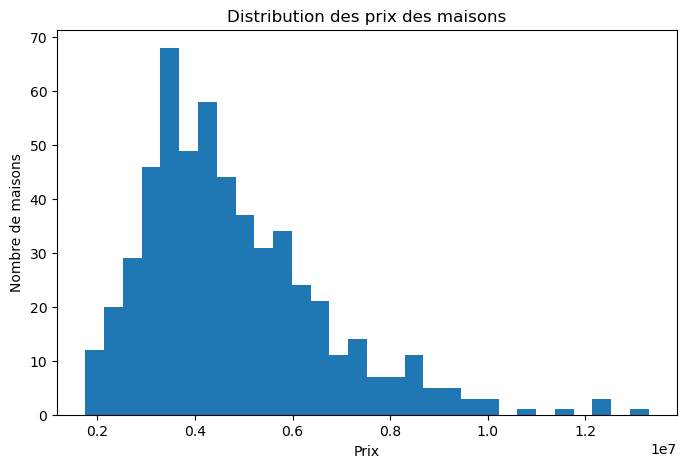

In [18]:
# DISTRIBUTION DU PRIX DES MAISONS


plt.figure(figsize=(8, 5))
plt.hist(housing_data["price"], bins=30)

plt.title("Distribution des prix des maisons")
plt.xlabel("Prix")
plt.ylabel("Nombre de maisons")

plt.show()

La distribution est asymétrique à droite (right-skewed)

Beaucoup de maisons sont entre 2M et 6M

Quelques maisons vont jusqu’à 13M+

##Interpretation : 

Le marché est donc dominé par des maisons milieu de gamme, avec quelques maisons haut de gamme (outliers)

##Impact ML : 

Le modèle peut être influencé par les maisons très chères
Possible amélioration future → log transformation

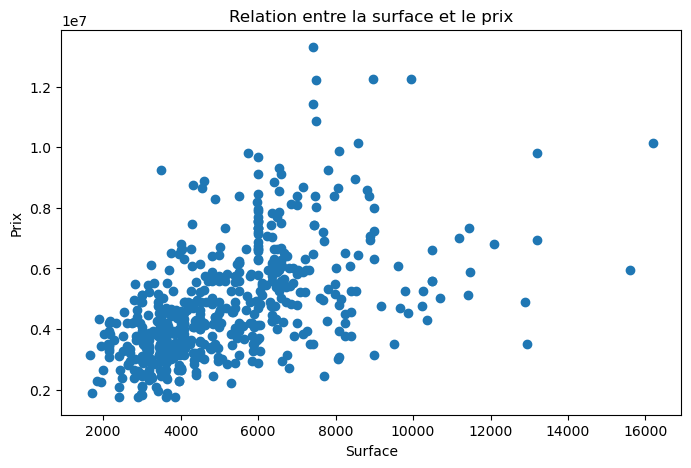

In [19]:
# RELATION ENTRE LA SURFACE ET LE PRIX
# ======================================

plt.figure(figsize=(8, 5))
plt.scatter(housing_data["area"], housing_data["price"])

plt.title("Relation entre la surface et le prix")
plt.xlabel("Surface")
plt.ylabel("Prix")

plt.show()

##Interpretation : 
Plus la surface augmente - plus le prix augmente, mais Pour une même surface, les prix varient beaucoup, donc d’autres variables influencent fortement le prix.

On peut conclure que area est importante, mais insuffisante seule

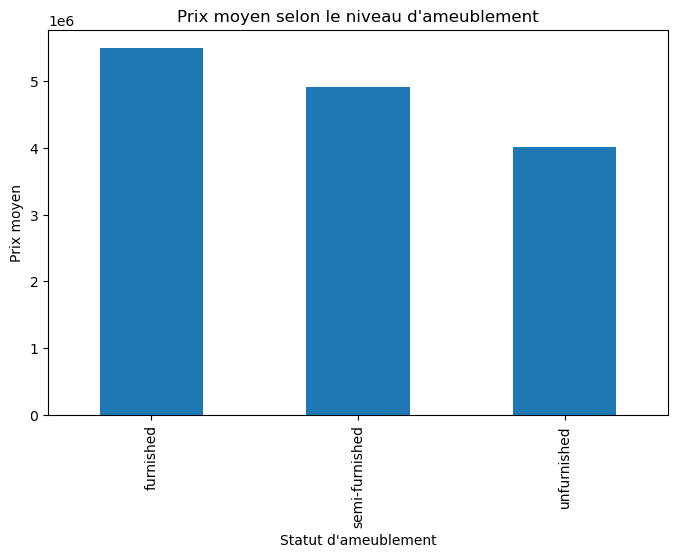

In [20]:
# PRIX MOYEN SELON LE NIVEAU D'AMEUBLEMENT

average_price_by_furnishing = housing_data.groupby("furnishingstatus")["price"].mean()

average_price_by_furnishing.plot(kind="bar", figsize=(8, 5))

plt.title("Prix moyen selon le niveau d'ameublement")
plt.xlabel("Statut d'ameublement")
plt.ylabel("Prix moyen")

plt.show()

Le niveau d’ameublement influence clairement le prix

In [21]:
# CORRÉLATION DES VARIABLES NUMÉRIQUES


correlation_with_price = housing_data.corr(numeric_only=True)["price"].sort_values(ascending=False)

correlation_with_price

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

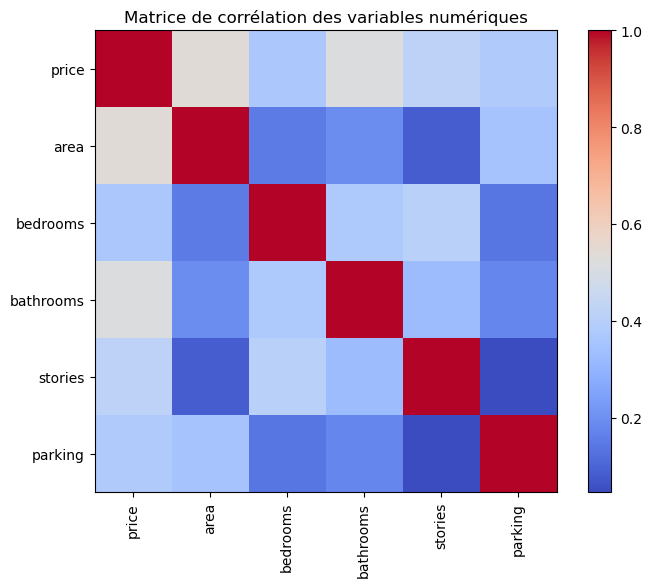

In [22]:
# MATRICE DE CORRÉLATION

correlation_matrix = housing_data.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Matrice de corrélation des variables numériques")

plt.show()

##Interprétation 

Variables les plus importantes :

area (surface)
c est le facteur principal du prix

bathrooms
c est l'indicateur de confort/luxe

stories
Plus la maison est grande, plus elle est chere

##RMQ :
 bedrooms < bathrooms
 -Le nombre de chambre ne caracterise le lux
 -la salle de bain = confort donc le prix augmente     

##Conclusion globale

L’analyse exploratoire montre que le prix des maisons est principalement influencé par la surface, le nombre de salles de bain et le nombre d’étages.
La distribution des prix est asymétrique avec quelques valeurs extrêmes.
Les variables liées au confort (comme furnishingstatus et bathrooms) ont un impact significatif sur le prix.
Le modèle doit donc combiner plusieurs variables pour être performant.